In [11]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


# Carregar os dataframes
df_regclim = pd.read_csv("/Users/biancarius/Desktop/CAETE-DVM-alloc-allom-including_alloc2_Cm2/scripts/yearly_mean_tables/MAN_regularclimate_yearly.csv")
df_2y = pd.read_csv("/Users/biancarius/Desktop/CAETE-DVM-alloc-allom-including_alloc2_Cm2/scripts/yearly_mean_tables/MAN_30prec_2y_yearly.csv")
df_4y = pd.read_csv("/Users/biancarius/Desktop/CAETE-DVM-alloc-allom-including_alloc2_Cm2/scripts/yearly_mean_tables/MAN_30prec_4y_yearly.csv")
df_6y = pd.read_csv("/Users/biancarius/Desktop/CAETE-DVM-alloc-allom-including_alloc2_Cm2/scripts/yearly_mean_tables/MAN_30prec_6y_yearly.csv")
df_8y = pd.read_csv("/Users/biancarius/Desktop/CAETE-DVM-alloc-allom-including_alloc2_Cm2/scripts/yearly_mean_tables/MAN_30prec_8y_yearly.csv")



In [21]:
# Carregar os dataframes
df_regclim_m = pd.read_csv("/Users/biancarius/Desktop/CAETE-DVM-alloc-allom-including_alloc2_Cm2/scripts/monthly_mean_tables/MAN_regularclimate_monthly.csv")
df_2y_m = pd.read_csv("/Users/biancarius/Desktop/CAETE-DVM-alloc-allom-including_alloc2_Cm2/scripts/monthly_mean_tables/MAN_30prec_2y_monthly.csv")
df_4y_m = pd.read_csv("/Users/biancarius/Desktop/CAETE-DVM-alloc-allom-including_alloc2_Cm2/scripts/monthly_mean_tables/MAN_30prec_4y_monthly.csv")
df_6y_m = pd.read_csv("/Users/biancarius/Desktop/CAETE-DVM-alloc-allom-including_alloc2_Cm2/scripts/monthly_mean_tables/MAN_30prec_6y_monthly.csv")
df_8y_m = pd.read_csv("/Users/biancarius/Desktop/CAETE-DVM-alloc-allom-including_alloc2_Cm2/scripts/monthly_mean_tables/MAN_30prec_8y_monthly.csv")



Yearly

In [13]:
# Variables of interest
variables = ['npp', 'ctotal', 'evapm', 'ls']

# Mapping variable names to plot labels
variables_label = {
    'npp': 'NPP',
    'ctotal': 'Total Carbon',
    'evapm': 'Evapotranspiration',
    'ls': 'Num. PLSs'
}

# Compute relative differences (%) with respect to the regular climate scenario
for var in variables:
    df_2y[var + '_diff_relative'] = (
        (df_2y[var] - df_regclim[var]) / df_regclim[var]
    ) * 100

    df_4y[var + '_diff_relative'] = (
        (df_4y[var] - df_regclim[var]) / df_regclim[var]
    ) * 100

    df_6y[var + '_diff_relative'] = (
        (df_6y[var] - df_regclim[var]) / df_regclim[var]
    ) * 100

    df_8y[var + '_diff_relative'] = (
        (df_8y[var] - df_regclim[var]) / df_regclim[var]
    ) * 100


monthly

In [22]:
# Variables of interest
variables = ['npp', 'ctotal', 'evapm', 'ls']

# Mapping variable names to plot labels
variables_label = {
    'npp': 'NPP',
    'ctotal': 'Total Carbon',
    'evapm': 'Evapotranspiration',
    'ls': 'Num. PLSs'
}

# Compute relative differences (%) with respect to the regular climate scenario
for var in variables:
    df_2y_m[var + '_diff_relative_m'] = (
        (df_2y_m[var] - df_regclim_m[var]) / df_regclim_m[var]
    ) * 100

    df_4y_m[var + '_diff_relative_m'] = (
        (df_4y_m[var] - df_regclim_m[var]) / df_regclim_m[var]
    ) * 100

    df_6y_m[var + '_diff_relative_m'] = (
        (df_6y_m[var] - df_regclim_m[var]) / df_regclim_m[var]
    ) * 100

    df_8y_m[var + '_diff_relative_m'] = (
        (df_8y_m[var] - df_regclim_m[var]) / df_regclim_m[var]
    ) * 100


In [15]:
# Create simulation year (starting at 0)
df_regclim['sim_year'] = range(len(df_regclim))
df_2y['sim_year'] = range(len(df_2y))
df_4y['sim_year'] = range(len(df_4y))
df_6y['sim_year'] = range(len(df_6y))
df_8y['sim_year'] = range(len(df_8y))


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# -----------------------------
# Colors (colorblind-friendly)
# -----------------------------
colors = {
    "npp":    "#3B5BA9",  # blue
    "ctotal": "#2A9D8F",  # teal
    "evapm":  "#8C2D3E",  # wine
    "ls":     "#B58900",  # mustard
}

# -----------------------------
# Scenario dataframes (already prepared)
# -----------------------------
scenarios = {
    "every 2y": df_2y,
    "every 4y": df_4y,
    "every 6y": df_6y,
    "every 8y": df_8y,
}

# Desired plotting order + display labels
order = ["every 8y", "every 6y", "every 4y", "every 2y"]
title_map = {
    "every 8y": "Reduced precipitation: every 8 years",
    "every 6y": "Reduced precipitation: every 6 years",
    "every 4y": "Reduced precipitation: every 4 years",
    "every 2y": "Reduced precipitation: every 2 years",
}

sns.set_style("white")

fig, axes = plt.subplots(
    nrows=2, ncols=2,
    figsize=(12, 7),
    sharex=True, sharey=True
)
axes = axes.flatten()

# -----------------------------
# Helper: drought barcode (top + bottom)
# -----------------------------
def add_drought_barcode(ax, drought_sim_years, height=0.04, color="0.2",
                        alpha_bottom=0.08, alpha_top=0.08):
    for y in drought_sim_years:
        # bottom strip
        ax.axvspan(
            y - 0.5, y + 0.5,
            ymin=0.0, ymax=height,
            color=color, alpha=alpha_bottom,
            lw=0, zorder=0
        )
        # top strip
        ax.axvspan(
            y - 0.5, y + 0.5,
            ymin=1.0 - height, ymax=1.0,
            color=color, alpha=alpha_top,
            lw=0, zorder=0
        )

# Max x for ticks
max_year = int(df_regclim["sim_year"].max())

# -----------------------------
# Draw panels
# -----------------------------
for ax, sc_name in zip(axes, order):
    df_sc = scenarios[sc_name]

    # drought years: sim_year=0 normal, first drought at sim_year=1, then every k years
    k = int(sc_name.split()[1].replace("y", ""))  # "every 4y" -> 4
    drought_sim_years = [y for y in range(0, max_year + 1) if (y >= 1 and (y - 1) % k == 0)]

    # make 2y extra subtle to avoid zebra
    alpha = 0.04 if k == 2 else 0.08
    add_drought_barcode(
        ax,
        drought_sim_years,
        height=0.04,
        color="0.2",
        alpha_bottom=alpha,
        alpha_top=alpha
    )

    # lines
    for var in variables:
        sns.lineplot(
            data=df_sc,
            x="sim_year",
            y=f"{var}_diff_relative",
            ax=ax,
            color=colors[var],
            linewidth=2.0,
            label=variables_label[var]#,
            # zorder=2
        )

    # 0% reference line
    ax.axhline(0, color="black", linestyle="--", linewidth=1, zorder=1)

    # Title (with "years")
    ax.set_title(title_map[sc_name], fontsize=12)

    # Clean look
    ax.grid(False)
    sns.despine(ax=ax)

    # Remove per-axis legend
    if ax.get_legend() is not None:
        ax.legend_.remove()

    # Remove axis *labels* (so "sim_year" and "npp_diff_relative" never appear)
    ax.set_xlabel("")
    ax.set_ylabel("")
        # Force y axis to percentage scale
    ax.set_ylim(-100, 10)
    ax.set_yticks([0, -25, -50, -75, -100])
    ax.set_yticklabels(["0", "-25", "-50", "-75", "-100"])


# -----------------------------
# Common axis labels
# -----------------------------
fig.supxlabel("Simulation year", fontsize=13)
fig.supylabel("Change relative to regular climate (%)", fontsize=13)

# X ticks: 0, 5, 10, ...
for ax in axes:
    ax.set_xticks(range(0, max_year + 1, 5))

# -----------------------------
# One legend for the entire figure
# -----------------------------
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles, labels,
    loc="lower center",
    ncol=4,
    frameon=False,
    fontsize=11,
    bbox_to_anchor=(0.5, -0.02)
)

plt.tight_layout()
plt.subplots_adjust(bottom=0.12)
plt.show()




In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'Helvetica']
plt.rcParams['font.size'] = 8

# -----------------------------
# Scenario dataframes (already prepared)
# -----------------------------
# Assumes each dataframe already contains:
# - 'sim_year'
# - '{var}_diff_relative' columns for var in variables
scenarios = {
    "2y": df_2y,
    "4y": df_4y,
    "6y": df_6y,
    "8y": df_8y,
}

# Plot order (from least frequent drought to most frequent)
order = ["8y", "6y", "4y", "2y"]

# -----------------------------
# Variables and labels
# -----------------------------
variables = ["npp", "ctotal", "evapm", "ls"]
variables_label = {
    "npp": "NPP",
    "ctotal": "Total carbon",
    "evapm": "Evapotranspiration",
    "ls": "Surviving strategies",
}

# -----------------------------
# Frequency colors (user-specified)
# -----------------------------
# freq_colors = {
#     "8y": "#3B5BA9",  # blue
#     "6y": "#2A9D8F",  # teal
#     "4y": "#B58900",  # mustard
#     "2y": "#8C2D3E",  # wine
# }

freq_colors = {
    "8y": "#0072B2",  # Azul forte
    "6y": "#2A9D8F",  # teal
    "4y": "#B58900",  # mustard
    "2y": "#8C2D3E",  # wine
}

# -----------------------------
# Plot settings (clean, Nature-like)
# -----------------------------
sns.set_style("white")

fig, axes = plt.subplots(
    nrows=2, ncols=2,
    figsize=(12, 7),
    sharex=True,
    sharey=False
)
axes = axes.flatten()

# Determine maximum simulation year for tick marks
max_year = int(df_regclim["sim_year"].max())

# -----------------------------
# Draw each variable in its own panel
# -----------------------------
for ax, var in zip(axes, variables):

    for sc in order:
        df_sc = scenarios[sc]

        sns.lineplot(
            data=df_sc,
            x="sim_year",
            y=f"{var}_diff_relative",
            ax=ax,
            linewidth=2.2,
            label=sc,
            color=freq_colors[sc],
        )

    ax.axhline(0, color="grey", linestyle="--", linewidth=1)
    ax.axhline(-50, color="grey", linestyle="--", linewidth=1)
    ax.set_title(variables_label[var], fontsize=12)
    ax.grid(False)
    sns.despine(ax=ax)
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.set_ylim(-100, 0)
    ax.set_yticks([10, 0, -20, -40, -60, -80, -100])
    ax.set_yticklabels(["","0", "-20", "-40", "-60","-80",  "-100"])

    if ax.get_legend() is not None:
        ax.legend_.remove()


# -----------------------------
# Common axis labels
# -----------------------------
fig.supxlabel("Year", fontsize=13, y=0.06)
fig.supylabel("Relative change to baseline (%)", fontsize=13)

# X ticks: 0, 5, 10, ...
for ax in axes:
    ax.set_xticks(range(0, max_year + 1, 5))

# -----------------------------
# One shared legend (frequencies)
# -----------------------------
handles, labels = axes[0].get_legend_handles_labels()

# Make legend labels a bit more explicit (optional)
label_map = {"8y": "8", "6y": "6", "4y": "4", "2y": "2"}
labels = [label_map.get(l, l) for l in labels]

fig.legend(
    handles, labels,
    title = "Recurrence (years)",
    loc="lower center",
    ncol=4,
    frameon=False,
    fontsize=11,
    bbox_to_anchor=(0.5, -0.03)
)

plt.tight_layout()
plt.subplots_adjust(bottom=0.14)  # space for legend
plt.show()




In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Configuração global de fontes para Nature (Arial/Helvetica)
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'Helvetica']
plt.rcParams['font.size'] = 8  # Nature usa tipografia pequena (7-8pt)

# -----------------------------
# Scenario dataframes (Assumindo que já estão carregados)
# -----------------------------
scenarios = {
    "2y": df_2y,
    "4y": df_4y,
    "6y": df_6y,
    "8y": df_8y,
}

order = ["8y", "6y", "4y", "2y"]

# -----------------------------
# Variáveis e Labels
# -----------------------------
variables = ["npp", "ctotal", "evapm", "ls"]
variables_label = {
    "npp": "NPP",
    "ctotal": "Total carbon",
    "evapm": "Evapotranspiration",
    "ls": "Surviving strategies",
}

# Paleta Colorblind-friendly (Nature compliant)
freq_colors = {
    "8y": "#0072B2",  # Azul
    "6y": "#2A9D8F",  # Verde azulado
    "4y": "#B58900",  # Dourado
    "2y": "#8C2D3E",  # Vinho
}

label_map = {"8y": "8", "6y": "6", "4y": "4", "2y": "2"}

# -----------------------------
# Plot settings
# -----------------------------
sns.set_style("white")

# Tamanho padrão para coluna dupla da Nature (aprox 180mm de largura)
fig, axes = plt.subplots(
    nrows=2, ncols=2,
    figsize=(10, 6), 
    sharex=True,
    sharey=False
)
axes = axes.flatten()

max_year = int(df_regclim["sim_year"].max())
panel_labels = ["a", "b", "c", "d"]

# -----------------------------
# Loop de Construção dos Painéis
# -----------------------------
for i, (ax, var) in enumerate(zip(axes, variables)):
    
    for sc in order:
        df_sc = scenarios[sc]
        y_data = df_sc[f"{var}_diff_relative"]
        x_data = df_sc["sim_year"]

        # Melhora visual: Interrompe a linha logo após atingir -100 (Colapso)
        # Isso evita que as linhas fiquem sobrepostas no eixo X
        mask_dead = y_data <= -99.9
        if mask_dead.any():
            idx_death = mask_dead.idxmax()
            x_plot = x_data[:idx_death + 1]
            y_plot = y_data[:idx_death + 1]
        else:
            x_plot = x_data
            y_plot = y_data

        ax.plot(
            x_plot,
            y_plot,
            linewidth=1.8,
            color=freq_colors[sc],
            label=label_map[sc]
        )

    # Identificadores de Painel (Estilo Nature: Negrito, canto superior esquerdo)
    ax.text(-0.08, 1.08, panel_labels[i], transform=ax.transAxes,
            fontsize=11, fontweight='bold', va='top', ha='right')

    # Linhas de referência (Suavizadas)
    ax.axhline(0, color="black", linewidth=0.6, alpha=0.8)
    ax.axhline(-50, color="darkgrey", linestyle="--", linewidth=0.8, alpha=0.8)
    
    # Títulos e Eixos
    ax.set_title(variables_label[var], fontsize=10, pad=8)
    ax.set_ylim(-105, 5)
    ax.set_yticks([10, 0, -20, -40, -60, -80, -100])
    ax.set_yticklabels(["","0", "-20", "-40", "-60", "-80", "-100"])
    
    ax.set_xticks(range(0, max_year + 1, 5))
    sns.despine(ax=ax)

    # Legenda Compacta dentro do painel (d)
    if i == 3:
        ax.legend(
            title="Recurrence (years)",
            title_fontsize=8,
            fontsize=8,
            loc="lower left",
            frameon=False,
            ncol=2
        )

# Rótulos comuns dos eixos
fig.supxlabel("Year", fontsize=10)
fig.supylabel("Relative change to baseline (%)", fontsize=10)

plt.tight_layout()
# Ajuste para garantir que os identificadores 'a, b...' não sejam cortados
plt.subplots_adjust(top=0.92, left=0.1, bottom=0.12)

# Salvar em formato vetorial para submissão
# plt.savefig('figura_resilience.pdf', dpi=300, bbox_inches='tight')

plt.show()

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# Global font configuration for Nature (Arial/Helvetica)
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'Helvetica']
plt.rcParams['font.size'] = 8  # Standard Nature font size (7-8pt)

# -----------------------------
# Data Setup
# -----------------------------
# Annual dataframes
scenarios_ann = {
    "2y": df_2y,
    "4y": df_4y,
    "6y": df_6y,
    "8y": df_8y,
}

# Monthly dataframes
scenarios_mon = {
    "2y": df_2y_m,
    "4y": df_4y_m,
    "6y": df_6y_m,
    "8y": df_8y_m,
}

order = ["8y", "6y", "4y", "2y"]
START_YEAR = 1979  # Base year to normalize simulation time to 0

# -----------------------------
# Variables and Labels
# -----------------------------
variables = ["npp", "ctotal", "evapm", "ls"]
variables_label = {
    "npp": "NPP",
    "ctotal": "Total carbon",
    "evapm": "Evapotranspiration",
    "ls": "Surviving strategies",
}

# Colorblind-friendly palette (Okabe-Ito based)
freq_colors = {
    "8y": "#0072B2",  # Blue
    "6y": "#2A9D8F",  # Teal
    "4y": "#B58900",  # Mustard
    "2y": "#8C2D3E",  # Wine
}

label_map = {"8y": "8", "6y": "6", "4y": "4", "2y": "2"}

# -----------------------------
# Plot settings
# -----------------------------
sns.set_style("white")

# Standard double-column width for Nature (approx. 180mm)
fig, axes = plt.subplots(
    nrows=2, ncols=2,
    figsize=(10, 6.5), 
    sharex=True,
    sharey=False
)
axes = axes.flatten()

max_year = int(df_2y["sim_year"].max()) # Use any df to get max year
panel_labels = ["a", "b", "c", "d"]

# -----------------------------
# Panel Construction Loop
# -----------------------------
for i, (ax, var) in enumerate(zip(axes, variables)):
    
    for sc in order:
        # --- 1. Monthly Shaded Area (Variability Envelope) ---
        df_m = scenarios_mon[sc].copy()
        df_m['date_dt'] = pd.to_datetime(df_m['date'])
        # Normalize year to start at 0
        df_m['sim_year'] = df_m['date_dt'].dt.year - START_YEAR
        
        # Aggregate monthly min/max per simulation year
        stats_yearly = df_m.groupby('sim_year')[f"{var}_diff_relative_m"].agg(['min', 'max']).reset_index()
        
        ax.fill_between(
            stats_yearly['sim_year'], 
            stats_yearly['min'], 
            stats_yearly['max'],
            color=freq_colors[sc],
            alpha=0.12,  # Subtle shade for readability
            linewidth=0,
            zorder=1
        )

        # --- 2. Annual Mean Lines ---
        df_a = scenarios_ann[sc]
        y_data = df_a[f"{var}_diff_relative"]
        x_data = df_a["sim_year"]

        # Visual cleanup: stop line immediately after reaching -100% (Collapse)
        # Prevents messy overlapping lines on the X-axis
        mask_dead = y_data <= -99.9
        if mask_dead.any():
            idx_death = mask_dead.idxmax()
            x_plot = x_data[:idx_death + 1]
            y_plot = y_data[:idx_death + 1]
        else:
            x_plot = x_data
            y_plot = y_data

        ax.plot(
            x_plot,
            y_plot,
            linewidth=1.8,
            color=freq_colors[sc],
            label=label_map[sc],
            zorder=10 # Ensure mean line stays above the shaded area
        )

    # Panel Identifiers (Nature style: Bold, top-left)
    ax.text(-0.08, 1.08, panel_labels[i], transform=ax.transAxes,
            fontsize=11, fontweight='bold', va='top', ha='right')

    # Reference Lines (Baseline and 50% threshold)
    ax.axhline(0, color="black", linewidth=0.6, alpha=0.8)
    ax.axhline(-50, color="darkgrey", linestyle="--", linewidth=0.8, alpha=0.8)
    
    # Titles and Axis refinement
    ax.set_title(variables_label[var], fontsize=10, pad=10)
    ax.set_ylim(-105, 15) # Increased upper limit to accommodate monthly spikes
    ax.set_yticks([10, 0, -20, -40, -60, -80, -100])
    ax.set_yticklabels(["", "0", "-20", "-40", "-60", "-80", "-100"])
    
    ax.set_xticks(range(0, max_year + 1, 5))
    sns.despine(ax=ax)

    # Compact Legend inside panel (d) to save vertical space
    if i == 3:
        ax.legend(
            title="Recurrence (years)",
            title_fontsize=8,
            fontsize=8,
            loc="lower left",
            frameon=False,
            ncol=2
        )

# Common axis labels
fig.supxlabel("Year", fontsize=10)
fig.supylabel("Relative change to baseline (%)", fontsize=10)

plt.tight_layout()
# Adjust margins to ensure panel labels (a, b...) are not clipped
plt.subplots_adjust(top=0.90, left=0.1, bottom=0.12)

# Save as vector format for submission
# plt.savefig('figure_ecosystem_resilience.pdf', dpi=300, bbox_inches='tight')

plt.show()

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# Global font configuration for Nature (Arial/Helvetica)
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'Helvetica']
plt.rcParams['font.size'] = 8  # Standard Nature font size (7-8pt)

# ---------------------------------------------------------
# Data Setup
# ---------------------------------------------------------
scenarios_ann = {"2y": df_2y, "4y": df_4y, "6y": df_6y, "8y": df_8y}
scenarios_mon = {"2y": df_2y_m, "4y": df_4y_m, "6y": df_6y_m, "8y": df_8y_m}

order = ["8y", "6y", "4y", "2y"]
START_YEAR = 1979  # Normalizing x-axis to start at 0

variables = ["npp", "ctotal", "evapm", "ls"]
variables_label = {
    "npp": "NPP",
    "ctotal": "Total carbon",
    "evapm": "Evapotranspiration",
    "ls": "Number of surviving strategies",
}

# Colorblind-friendly palette
freq_colors = {
    "8y": "#0072B2", "6y": "#2A9D8F", "4y": "#B58900", "2y": "#8C2D3E"
}

label_map = {"8y": "8", "6y": "6", "4y": "4", "2y": "2"}

# ---------------------------------------------------------
# Plotting
# ---------------------------------------------------------
sns.set_style("white")

fig, axes = plt.subplots(
    nrows=2, ncols=2,
    figsize=(10, 6.5), 
    sharex=True,
    sharey=False
)
axes = axes.flatten()

max_year = int(df_2y["sim_year"].max()) 
panel_labels = ["a", "b", "c", "d"]

for i, (ax, var) in enumerate(zip(axes, variables)):
    
    for sc in order:
        # --- 1. Monthly Shaded Area (Variability Envelope) ---
        # Only apply shading to continuous biogeochemical variables (a, b, c)
        if var != "ls":
            df_m = scenarios_mon[sc].copy()
            df_m['date_dt'] = pd.to_datetime(df_m['date'])
            df_m['sim_year'] = df_m['date_dt'].dt.year - START_YEAR
            
            stats_yearly = df_m.groupby('sim_year')[f"{var}_diff_relative_m"].agg(['min', 'max']).reset_index()
            
            ax.fill_between(
                stats_yearly['sim_year'], 
                stats_yearly['min'], 
                stats_yearly['max'],
                color=freq_colors[sc],
                alpha=0.12,
                linewidth=0,
                zorder=1
            )

        # --- 2. Annual Mean Lines ---
        df_a = scenarios_ann[sc]
        y_data = df_a[f"{var}_diff_relative"]
        x_data = df_a["sim_year"]

        # Stop lines immediately after total collapse (-100%)
        mask_dead = y_data <= -99.9
        if mask_dead.any():
            idx_death = mask_dead.idxmax()
            x_plot = x_data[:idx_death + 1]
            y_plot = y_data[:idx_death + 1]
        else:
            x_plot = x_data
            y_plot = y_data

        if var == "ls":
            # Discrete extinctions: Use step plot without shading
            ax.step(
                x_plot, y_plot, 
                where='post', 
                linewidth=1.8, 
                color=freq_colors[sc], 
                label=label_map[sc], 
                zorder=10
            )
        else:
            # Continuous fluxes: Use standard lines
            ax.plot(
                x_plot, y_plot, 
                linewidth=1.8, 
                color=freq_colors[sc], 
                label=label_map[sc], 
                zorder=10
            )

    # --- 3. Refinement & Styling ---
    # Panel Labels (Bold, top-left)
    ax.text(-0.08, 1.08, panel_labels[i], transform=ax.transAxes,
            fontsize=11, fontweight='bold', va='top', ha='right')

    # Reference lines (0% baseline and -50% threshold)
    ax.axhline(0, color="black", linewidth=0.6, alpha=0.8)
    ax.axhline(-50, color="darkgrey", linestyle="--", linewidth=0.8, alpha=0.8)
    
    ax.set_title(variables_label[var], fontsize=10, pad=10)
    
    # Consistent Y-axis for all panels
    ax.set_ylim(-105, 15) 
    ax.set_yticks([10, 0, -20, -40, -60, -80, -100])
    ax.set_yticklabels(["", "0", "-20", "-40", "-60", "-80", "-100"])
    
    ax.set_xticks(range(0, max_year + 1, 5))
    sns.despine(ax=ax)

    if i == 3:
        ax.legend(
            title="Recurrence (years)",
            title_fontsize=8,
            fontsize=8,
            loc="lower left",
            frameon=False,
            ncol=2
        )

# Global axis labels
fig.supxlabel("Years", fontsize=10)
fig.supylabel("Relative change to baseline (%)", fontsize=10)

plt.tight_layout()
plt.subplots_adjust(top=0.90, left=0.1, bottom=0.12)

plt.show()

Figure X | Temporal response of ecosystem state indicators to recurrent droughts. Time series of the relative change (%) in ecosystem state indicators compared to a baseline simulation under historical climate conditions. Shown are (a) net primary productivity (NPP), (b) total ecosystem carbon, (c) evapotranspiration, and (d) the number of surviving plant strategies. Simulations differ by the recurrence of reduced precipitation events (−50%), applied every 8, 6, 4, or 2 years. Solid lines represent yearly means, computed using a 12-month rolling window to reduce intra-annual variability. Shaded envelopes indicate the minimum and maximum values across the rolling window. The horizontal dashed line marks a 50% change relative to the baseline, included as a visual reference to facilitate comparison across variables and scenarios. The number of surviving strategies (panel d) is shown using a step plot, reflecting its discrete and cumulative nature, with changes occurring only when strategies go extinct. The x-axis represents simulation years since the start of the drought experiment.

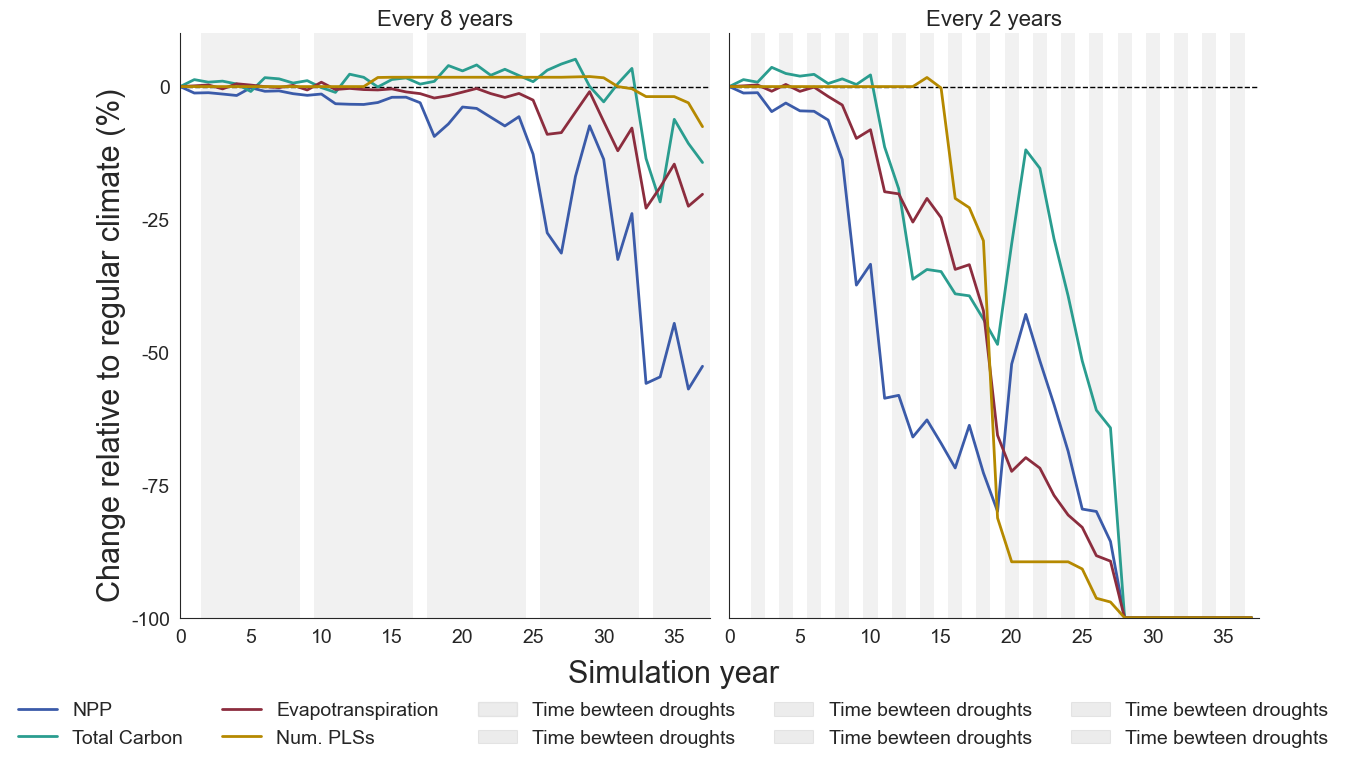

In [68]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches  # <-- ADICIONE ESTA LINHA AQUI
import seaborn as sns
import pandas as pd

# Carregar os dataframes
df_regclim = pd.read_csv("/Users/biancarius/Desktop/CAETE-DVM-alloc-allom-including_alloc2_Cm2/scripts/yearly_mean_tables/MAN_regularclimate_yearly.csv")
df_2y = pd.read_csv("/Users/biancarius/Desktop/CAETE-DVM-alloc-allom-including_alloc2_Cm2/scripts/yearly_mean_tables/MAN_30prec_2y_yearly.csv")
df_8y = pd.read_csv("/Users/biancarius/Desktop/CAETE-DVM-alloc-allom-including_alloc2_Cm2/scripts/yearly_mean_tables/MAN_30prec_8y_yearly.csv")

# Create simulation year (starting at 0)
df_regclim['sim_year'] = range(len(df_regclim))
df_2y['sim_year'] = range(len(df_2y))
df_8y['sim_year'] = range(len(df_8y))

# Variables of interest
variables = ['npp', 'ctotal', 'evapm', 'ls']

# Mapping variable names to plot labels
variables_label = {
    'npp': 'NPP',
    'ctotal': 'Total Carbon',
    'evapm': 'Evapotranspiration',
    'ls': 'Num. PLSs'
}

# Compute relative differences (%) with respect to the regular climate scenario
for var in variables:
    df_2y[var + '_diff_relative'] = (
        (df_2y[var] - df_regclim[var]) / df_regclim[var]
    ) * 100

    df_8y[var + '_diff_relative'] = (
        (df_8y[var] - df_regclim[var]) / df_regclim[var]
    ) * 100

# -----------------------------
# Colors (colorblind-friendly)
# -----------------------------
colors = {
    "npp":    "#3B5BA9",  # blue
    "ctotal": "#2A9D8F",  # teal
    "evapm":  "#8C2D3E",  # wine
    "ls":     "#B58900",  # mustard
}

# -----------------------------
# Scenario dataframes (already prepared)
# -----------------------------
scenarios = {
    "every 2y": df_2y,
    "every 8y": df_8y,
}

# Desired plotting order + display labels
order = ["every 8y", "every 2y"]
title_map = {
    "every 8y": "Every 8 years",
    "every 2y": "Every 2 years",
}

sns.set_style("white")

fig, axes = plt.subplots(
    nrows=1, ncols=2,
    figsize=(12, 7),
    sharex=True, sharey=True
)
axes = axes.flatten()

# -----------------------------
# Helper: drought barcode (top + bottom)
# -----------------------------
def add_drought_barcode(ax, drought_sim_years, height=0.04, color="0.2",
                        alpha_bottom=0.08, alpha_top=0.08):
    for y in drought_sim_years:
        # bottom strip
        ax.axvspan(
            y - 0.5, y + 0.5,
            ymin=0.0, ymax=height,
            color=color, alpha=alpha_bottom,
            lw=0, zorder=0
        )
        # top strip
        ax.axvspan(
            y - 0.5, y + 0.5,
            ymin=1.0 - height, ymax=1.0,
            color=color, alpha=alpha_top,
            lw=0, zorder=0
        )

def add_inter_drought_shading(ax, drought_sim_years, max_year, color="gray", alpha=0.15):
    if not drought_sim_years:
        return

    # Apenas sombrear os intervalos ENTRE as secas (ignorando o ano 0)
    for i in range(len(drought_sim_years) - 1):
        start = drought_sim_years[i] + 0.5
        end = drought_sim_years[i+1] - 0.5
        
        if start < end: 
            ax.axvspan(start, end, color=color, alpha=alpha, zorder=0, lw=0)

    # Sombrear da última seca até o final
    last_drought = drought_sim_years[-1]
    if last_drought + 0.5 < max_year:
        ax.axvspan(last_drought + 0.5, max_year + 0.5, color=color, alpha=alpha, zorder=0, lw=0)

# Max x for ticks
max_year = int(df_regclim["sim_year"].max())

# -----------------------------
# Draw panels
# -----------------------------
for ax, sc_name in zip(axes, order):
    df_sc = scenarios[sc_name]

    # drought years: sim_year=0 normal, first drought at sim_year=1, then every k years
    k = int(sc_name.split()[1].replace("y", ""))  # "every 4y" -> 4
    drought_sim_years = [y for y in range(0, max_year + 1) if (y >= 1 and (y - 1) % k == 0)]
    
    add_inter_drought_shading(ax, 
        drought_sim_years, 
        max_year=max_year, 
        color="gray", 
        alpha=0.11
    )

    # lines
    for var in variables:
        sns.lineplot(
            data=df_sc,
            x="sim_year",
            y=f"{var}_diff_relative",
            ax=ax,
            color=colors[var],
            linewidth=2.0,
            label=variables_label[var]
        )

    # 0% reference line
    ax.axhline(0, color="black", linestyle="--", linewidth=1, zorder=1)

    # Title (with "years")
    ax.set_title(title_map[sc_name], fontsize=16)
    ax.set_xlim(0, max_year + 0.5)

    # Clean look
    ax.grid(False)
    sns.despine(ax=ax)

    # Remove per-axis legend
    if ax.get_legend() is not None:
        ax.legend_.remove()

    # Remove axis *labels*
    ax.set_xlabel("")
    ax.set_ylabel("")
    
    # Force y axis to percentage scale
    ax.set_ylim(-100, 10)
    ax.set_yticks([0, -25, -50, -75, -100])
    ax.set_yticklabels(["0", "-25", "-50", "-75", "-100"])
    ax.tick_params(axis='both', labelsize=14)

# -----------------------------
# Common axis labels
# -----------------------------
fig.supxlabel("Simulation year", fontsize=22)
fig.supylabel("Change relative to regular climate (%)", fontsize=22)

# X ticks: 0, 5, 10, ...
for ax in axes:
    ax.set_xticks(range(0, max_year + 1, 5))
    
# Cria o "quadradinho" cinza para a legenda
shade_patch = mpatches.Patch(color='gray', alpha=0.15, label='')

handles.append(shade_patch)
labels.append('Time bewteen droughts')

# -----------------------------
# One legend for the entire figure
# -----------------------------
fig.legend(
    handles, labels,
    loc="lower center",
    ncol=5,
    frameon=False,
    fontsize=14,  # Ajustei para 14 para acompanhar o resto, mas pode mudar!
    bbox_to_anchor=(0.5, -0.1)  # <-- ALTERADO: Empurra a legenda mais para baixo (antes era -0.02)
)

plt.tight_layout()
plt.subplots_adjust(bottom=0.11)  # <-- ALTERADO: Aumenta a margem de baixo para caber tudo (antes era 0.12)
plt.show()

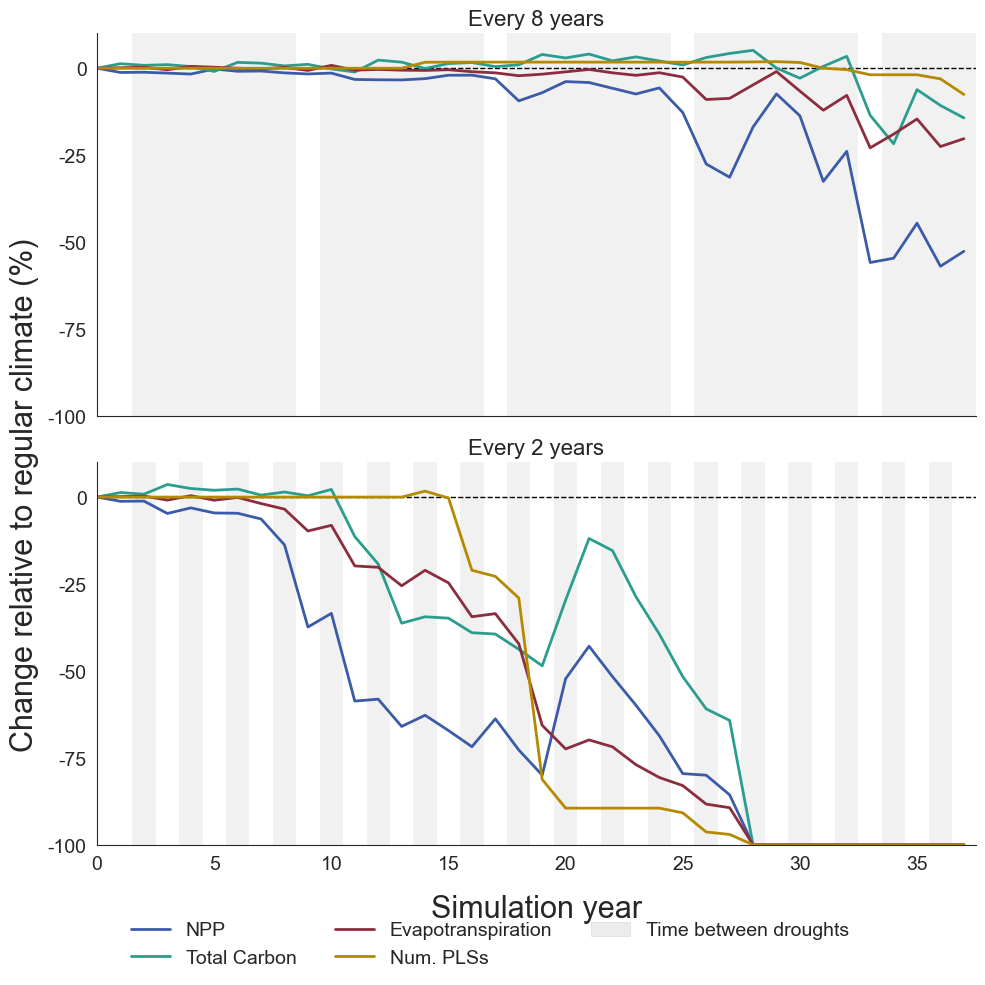

In [69]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import pandas as pd

# Carregar os dataframes
df_regclim = pd.read_csv("/Users/biancarius/Desktop/CAETE-DVM-alloc-allom-including_alloc2_Cm2/scripts/yearly_mean_tables/MAN_regularclimate_yearly.csv")
df_2y = pd.read_csv("/Users/biancarius/Desktop/CAETE-DVM-alloc-allom-including_alloc2_Cm2/scripts/yearly_mean_tables/MAN_30prec_2y_yearly.csv")
df_8y = pd.read_csv("/Users/biancarius/Desktop/CAETE-DVM-alloc-allom-including_alloc2_Cm2/scripts/yearly_mean_tables/MAN_30prec_8y_yearly.csv")

# Create simulation year (starting at 0)
df_regclim['sim_year'] = range(len(df_regclim))
df_2y['sim_year'] = range(len(df_2y))
df_8y['sim_year'] = range(len(df_8y))

# Variables of interest
variables = ['npp', 'ctotal', 'evapm', 'ls']

# Mapping variable names to plot labels
variables_label = {
    'npp': 'NPP',
    'ctotal': 'Total Carbon',
    'evapm': 'Evapotranspiration',
    'ls': 'Num. PLSs'
}

# Compute relative differences (%) with respect to the regular climate scenario
for var in variables:
    df_2y[var + '_diff_relative'] = (
        (df_2y[var] - df_regclim[var]) / df_regclim[var]
    ) * 100

    df_8y[var + '_diff_relative'] = (
        (df_8y[var] - df_regclim[var]) / df_regclim[var]
    ) * 100

# -----------------------------
# Colors (colorblind-friendly)
# -----------------------------
colors = {
    "npp":    "#3B5BA9",  # blue
    "ctotal": "#2A9D8F",  # teal
    "evapm":  "#8C2D3E",  # wine
    "ls":     "#B58900",  # mustard
}

# -----------------------------
# Scenario dataframes (already prepared)
# -----------------------------
scenarios = {
    "every 2y": df_2y,
    "every 8y": df_8y,
}

# Desired plotting order + display labels
order = ["every 8y", "every 2y"]
title_map = {
    "every 8y": "Every 8 years",
    "every 2y": "Every 2 years",
}

sns.set_style("white")

# <-- MUDANÇA AQUI: 2 linhas, 1 coluna e figura mais alta (10, 10)
fig, axes = plt.subplots(
    nrows=2, ncols=1,
    figsize=(10, 10),
    sharex=True, sharey=True
)
axes = axes.flatten()

# -----------------------------
# Helper functions
# -----------------------------
def add_drought_barcode(ax, drought_sim_years, height=0.04, color="0.2",
                        alpha_bottom=0.08, alpha_top=0.08):
    for y in drought_sim_years:
        ax.axvspan(y - 0.5, y + 0.5, ymin=0.0, ymax=height, color=color, alpha=alpha_bottom, lw=0, zorder=0)
        ax.axvspan(y - 0.5, y + 0.5, ymin=1.0 - height, ymax=1.0, color=color, alpha=alpha_top, lw=0, zorder=0)

def add_inter_drought_shading(ax, drought_sim_years, max_year, color="gray", alpha=0.15):
    if not drought_sim_years:
        return

    for i in range(len(drought_sim_years) - 1):
        start = drought_sim_years[i] + 0.5
        end = drought_sim_years[i+1] - 0.5
        if start < end: 
            ax.axvspan(start, end, color=color, alpha=alpha, zorder=0, lw=0)

    last_drought = drought_sim_years[-1]
    if last_drought + 0.5 < max_year:
        ax.axvspan(last_drought + 0.5, max_year + 0.5, color=color, alpha=alpha, zorder=0, lw=0)

# Max x for ticks
max_year = int(df_regclim["sim_year"].max())

# -----------------------------
# Draw panels
# -----------------------------
for ax, sc_name in zip(axes, order):
    df_sc = scenarios[sc_name]

    k = int(sc_name.split()[1].replace("y", "")) 
    drought_sim_years = [y for y in range(0, max_year + 1) if (y >= 1 and (y - 1) % k == 0)]
    
    add_inter_drought_shading(ax, 
        drought_sim_years, 
        max_year=max_year, 
        color="gray", 
        alpha=0.11
    )

    for var in variables:
        sns.lineplot(
            data=df_sc,
            x="sim_year",
            y=f"{var}_diff_relative",
            ax=ax,
            color=colors[var],
            linewidth=2.0,
            label=variables_label[var]
        )

    ax.axhline(0, color="black", linestyle="--", linewidth=1, zorder=1)

    ax.set_title(title_map[sc_name], fontsize=16)
    ax.set_xlim(0, max_year + 0.5)

    ax.grid(False)
    sns.despine(ax=ax)

    if ax.get_legend() is not None:
        ax.legend_.remove()

    ax.set_xlabel("")
    ax.set_ylabel("")
    
    ax.set_ylim(-100, 10)
    ax.set_yticks([0, -25, -50, -75, -100])
    ax.set_yticklabels(["0", "-25", "-50", "-75", "-100"])
    ax.tick_params(axis='both', labelsize=14)

# -----------------------------
# Common axis labels
# -----------------------------
# <-- MUDANÇA AQUI: Passei o texto do eixo X para o último painel, assim ele não sobrepõe a legenda
axes[-1].set_xlabel("Simulation year", fontsize=22, labelpad=15)
fig.supylabel("Change relative to regular climate (%)", fontsize=22)

# X ticks: 0, 5, 10, ...
for ax in axes:
    ax.set_xticks(range(0, max_year + 1, 5))
    
# <-- MUDANÇA AQUI: Adicionei a linha que extrai os handles antes do append
handles, labels = axes[0].get_legend_handles_labels()

# Cria o "quadradinho" cinza para a legenda
shade_patch = mpatches.Patch(color='gray', alpha=0.15, label='')
handles.append(shade_patch)
labels.append('Time between droughts')

# -----------------------------
# One legend for the entire figure
# -----------------------------
fig.legend(
    handles, labels,
    loc="lower center",
    ncol=3, # <-- MUDANÇA AQUI: Sugiro usar 3 colunas, pois com 5 a legenda pode ficar espremida e cortar o texto
    frameon=False,
    fontsize=14,  
    bbox_to_anchor=(0.5, 0.01)  # <-- Ajustado para a nova proporção vertical
)

plt.tight_layout()
plt.subplots_adjust(bottom=0.15)  # <-- Margem inferior suficiente para a legenda
plt.show()

FUNCTIONAL TRAITS

In [50]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D
from mpl_toolkits.axes_grid1.inset_locator import inset_axes



base_path = (
    "/Users/biancarius/Desktop/"
    "CAETE-DVM-alloc-allom-including_alloc2_Cm2/"
    "paper_resilience/tables_results/"
)

table_2y = pd.read_csv(
    f"{base_path}PLS_alive_traits_MAN_30prec_2y.csv"
)
table_2y["Source"] = "2y"

table_8y = pd.read_csv(
    f"{base_path}PLS_alive_traits_MAN_30prec_8y.csv"
)
table_8y["Source"] = "8y"

table_regclim = pd.read_csv(
    f"{base_path}PLS_alive_traits_MAN_regularclimate.csv"
)
table_regclim["Source"] = "regclim"


In [52]:

df = pd.concat(
    [table_regclim, table_2y, table_8y],
    ignore_index=True
)

df["Source"] = pd.Categorical(
    df["Source"],
    categories=["regclim", "8y", "2y"],
    ordered=True
)


In [ ]:
# Helper: weighted mean that returns NaN if total weight is 0/NaN
def weighted_mean(x, w):
    x = pd.to_numeric(x, errors="coerce")
    w = pd.to_numeric(w, errors="coerce")

    sw = np.nansum(w.values)
    if np.isfinite(sw) and sw > 0:
        return np.nansum((x * w).values) / sw
    return np.nan


trait_means = (
    df.groupby(["Source", "YEAR"], as_index=False)
      .agg(
          sum_OC=("OC", lambda s: np.nansum(pd.to_numeric(s, errors="coerce"))),
          mean_wd=("wd_random", lambda s: weighted_mean(s, df.loc[s.index, "OC"])),
          mean_sla=("sla_random", lambda s: weighted_mean(s * 1000, df.loc[s.index, "OC"])),
          mean_g1=("g1", lambda s: weighted_mean(s, df.loc[s.index, "OC"])),
      )
      .merge(year_map, on=["Source", "YEAR"], how="left")   # left_join
      .sort_values(["Source", "run_year"])                 # arrange
      .reset_index(drop=True)
)

In [ ]:
year_map = (
    df[["Source", "YEAR"]]
    .drop_duplicates()
    .sort_values(["Source", "YEAR"])
    .assign(
        run_year=lambda x: x.groupby("Source").cumcount()
    )
    .reset_index(drop=True)
)


In [ ]:
# Helper: weighted mean that returns NaN if total weight is 0/NaN
def weighted_mean(x, w):
    x = pd.to_numeric(x, errors="coerce")
    w = pd.to_numeric(w, errors="coerce")

    sw = np.nansum(w.values)
    if np.isfinite(sw) and sw > 0:
        return np.nansum((x * w).values) / sw
    return np.nan


trait_means = (
    df.groupby(["Source", "YEAR"], as_index=False)
      .agg(
          sum_OC=("OC", lambda s: np.nansum(pd.to_numeric(s, errors="coerce"))),
          mean_wd=("wd_random", lambda s: weighted_mean(s, df.loc[s.index, "OC"])),
          mean_sla=("sla_random", lambda s: weighted_mean(s * 1000, df.loc[s.index, "OC"])),
          mean_g1=("g1", lambda s: weighted_mean(s, df.loc[s.index, "OC"])),
      )
      .merge(year_map, on=["Source", "YEAR"], how="left")   # left_join
      .sort_values(["Source", "run_year"])                 # arrange
      .reset_index(drop=True)
)

In [ ]:


sns.set_style("white")
sns.set_context("paper", font_scale=1.0)

# rcParams mais "journal"
plt.rcParams.update({
    "font.family": "DejaVu Sans",   # se tiver Arial/Helvetica instalado, melhor ainda
    "axes.linewidth": 0.8,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.major.size": 4,
    "ytick.major.size": 4,
    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,
})

freq_colors = {
    "regclim": "#000000",
    "8y": "#3B5BA9",
    "6y": "#2A9D8F",
    "4y": "#B58900",
    "2y": "#8C2D3E",
}
order = ["regclim", "8y", "2y"]

traits = ["mean_wd", "mean_sla", "mean_g1"]
traits_label = {
    "mean_wd": r"Wood density (g cm$^{-3}$)",
    "mean_sla": r"SLA (m$^2$ kg$^{-1}$)",
    "mean_g1": r"g1 (kPa$^{0.5}$)",
}

fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(8.6, 7.6), sharex=True)
max_run = int(trait_means["run_year"].max())


for i, (ax, tr) in enumerate(zip(axes, traits)):

    for sc in order:
        df_sc = trait_means.loc[trait_means["Source"] == sc].sort_values("run_year")
        if df_sc.empty:
            continue

        lw = 1.8 if sc == "regclim" else 1.8
        ax.plot(
            df_sc["run_year"], df_sc[tr],
            color=freq_colors[sc],
            linewidth=lw,
            solid_capstyle="round",
            label=sc
        )

    # título no canto, estilo facet
    ax.text(
        0.0, 1.03,
        f" {traits_label[tr]}",
        transform=ax.transAxes,
        ha="left", va="bottom",
        fontsize=11
    )

    ax.grid(False)
    sns.despine(ax=ax)

    # ticks visíveis e consistentes
    ax.tick_params(bottom=True, left=True, labelleft=True)

# eixo x (menos poluído)
xticks = [0, 5, 10, 15, 20, 25, 30, 35]
axes[-1].set_xticks(xticks)
axes[-1].set_xlabel("Simulation year", labelpad=10, fontsize=12.5)

# ylabel global
fig.supylabel("Trait weighted mean", x=0.02, fontsize=12.5)

# legenda única embaixo, em ordem fixa
label_map = {
    "regclim": "regular climate",
    "8y": "every 8y",
    "2y": "every 2y"
}
legend_handles = [Line2D([0], [0], color=freq_colors[k], lw=2.0 if k=="regclim" else 2.0) for k in order]
legend_labels  = [label_map[k] for k in order]

fig.legend(
    legend_handles, legend_labels,
    loc="lower center",
    ncol=5,
    frameon=False,
    bbox_to_anchor=(0.55, -0.015),
    handlelength=2.6
)

# -------- Optional (recomendado): inset zoom no g1 --------
# zoom para ver as séries "normais" sem o colapso esmagar o resto
# -------- Inset zoom no g1 (tudo translúcido) --------
ax_g1 = axes[2]

ins = inset_axes(ax_g1, width="39%", height="46%", loc="lower left", bbox_to_anchor=(0.03, 0.12, 1, 1),   # (x0, y0, width_ref, height_ref)
    bbox_transform=ax_g1.transAxes, borderpad=1.2)

# controle geral de "translucidez"
INSET_ALPHA = 0.70

# fundo + borda translúcidos
ins.set_facecolor("white")          # mantém legível
ins.patch.set_alpha(INSET_ALPHA)    # transparência do fundo
for spine in ins.spines.values():
    spine.set_alpha(INSET_ALPHA)
    spine.set_linewidth(0.7)

# linhas translúcidas
for sc in order:
    df_sc = trait_means.loc[trait_means["Source"] == sc].sort_values("run_year")
    if df_sc.empty:
        continue
    ins.plot(
        df_sc["run_year"], df_sc["mean_g1"],
        color=freq_colors[sc],
        linewidth=1.4,
        alpha=INSET_ALPHA,          # transparência das linhas
        solid_capstyle="round",
    )

ins.set_ylim(8.0, 10.2)
ins.set_xlim(0, max_run)

# ticks e labels translúcidos
ins.tick_params(
    labelsize=6.5,
    direction="in",
    length=3,
    width=0.7,
    colors=(0, 0, 0, INSET_ALPHA)   # aplica alpha ao texto e aos ticks
)

# (opcional) deixar também os números do tick com alpha garantido
for lab in ins.get_xticklabels() + ins.get_yticklabels():
    lab.set_alpha(INSET_ALPHA)


plt.tight_layout()
plt.subplots_adjust(bottom=0.13)
plt.show()


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
# Assumindo que o pandas e o seu dataframe 'trait_means' já estão carregados aqui

sns.set_style("white")
sns.set_context("paper", font_scale=1.0)

# rcParams mais "journal"
plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "axes.linewidth": 0.8,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.major.size": 4,
    "ytick.major.size": 4,
    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,
})

freq_colors = {
    "regclim": "#000000",
    "8y": "#3B5BA9",
    "6y": "#2A9D8F",
    "4y": "#B58900",
    "2y": "#8C2D3E",
}
order = ["regclim", "8y", "2y"]

traits = ["mean_wd", "mean_sla", "mean_g1"]
traits_label = {
    "mean_wd": r"Wood density (g cm$^{-3}$)",
    "mean_sla": r"SLA (m$^2$ kg$^{-1}$)",
    "mean_g1": r"g1 (kPa$^{0.5}$)",
}

# Aumentei um pouco a altura da figura (de 7.6 para 9.0) para acomodar as fontes maiores sem esmagar os painéis
fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(8.6, 9.0), sharex=True)
max_run = int(trait_means["run_year"].max())

for i, (ax, tr) in enumerate(zip(axes, traits)):

    for sc in order:
        df_sc = trait_means.loc[trait_means["Source"] == sc].sort_values("run_year")
        if df_sc.empty:
            continue

        lw = 1.8 if sc == "regclim" else 1.8
        ax.plot(
            df_sc["run_year"], df_sc[tr],
            color=freq_colors[sc],
            linewidth=lw,
            solid_capstyle="round",
            label=sc
        )

    # título no canto (Aumentado para fontsize=16)
    ax.text(
        0.0, 1.03,
        f" {traits_label[tr]}",
        transform=ax.transAxes,
        ha="left", va="bottom",
        fontsize=16
    )

    ax.grid(False)
    sns.despine(ax=ax)

    # ticks visíveis, consistentes e MAIORES (labelsize=14)
    ax.tick_params(bottom=True, left=True, labelleft=True, labelsize=14)
    ax.set_xlim(0, max_run)

# eixo x (menos poluído)
xticks = [0, 5, 10, 15, 20, 25, 30, 35]
axes[-1].set_xticks(xticks)

# Remove o xlabel padrão para usarmos o supxlabel global
axes[-1].set_xlabel("")

# Labels globais com a fonte grande (fontsize=22)
axes[-1].set_xlabel("Simulation year", fontsize=22, labelpad=10)
fig.supylabel("Trait weighted mean", x=0.02, fontsize=22)

# legenda única embaixo, em ordem fixa
label_map = {
    "regclim": "regular climate",
    "8y": "every 8y",
    "2y": "every 2y",
}
legend_handles = [Line2D([0], [0], color=freq_colors[k], lw=2.0) for k in order]
legend_labels  = [label_map[k] for k in order]

# Legenda ajustada (fontsize=14)
fig.legend(
    legend_handles, legend_labels,
    loc="lower center",
    ncol=3, # Ajustado para 3 colunas para acomodar os 5 itens em 2 linhas elegantemente
    frameon=False,
    fontsize=14,
    bbox_to_anchor=(0.55, -0.02),
    handlelength=2.6
)

# -------- Inset zoom no g1 (tudo translúcido) --------
ax_g1 = axes[2]

ins = inset_axes(ax_g1, width="39%", height="46%", loc="lower left", bbox_to_anchor=(0.03, 0.12, 1, 1), 
    bbox_transform=ax_g1.transAxes, borderpad=1.2)

# controle geral de "translucidez"
INSET_ALPHA = 0.70

# fundo + borda translúcidos
ins.set_facecolor("white")          
ins.patch.set_alpha(INSET_ALPHA)    
for spine in ins.spines.values():
    spine.set_alpha(INSET_ALPHA)
    spine.set_linewidth(0.7)

# linhas translúcidas
for sc in order:
    df_sc = trait_means.loc[trait_means["Source"] == sc].sort_values("run_year")
    if df_sc.empty:
        continue
    ins.plot(
        df_sc["run_year"], df_sc["mean_g1"],
        color=freq_colors[sc],
        linewidth=1.4,
        alpha=INSET_ALPHA,          
        solid_capstyle="round",
    )

ins.set_ylim(8.0, 10.2)
ins.set_xlim(0, max_run)

# ticks e labels translúcidos no zoom (mantive um tamanho menor aqui para não poluir, 8.5)
ins.tick_params(
    labelsize=8.5,
    direction="in",
    length=3,
    width=0.7,
    colors=(0, 0, 0, INSET_ALPHA)   
)

for lab in ins.get_xticklabels() + ins.get_yticklabels():
    lab.set_alpha(INSET_ALPHA)

plt.tight_layout()
plt.subplots_adjust(bottom=0.15, left=0.12) # Ajuste de margens para as fontes grandes caberem
plt.show()